In [1]:
import time
from pathlib import Path
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Activation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import Optimizer
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.models import save_model
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [2]:
class NNCar():
    def __init__(self): 
        super().__init__()
        #self.img_path = Path(__file__).parents[0].joinpath("images")
        self.img_size_for_resize = (128, 128)
        self.img_depth = 3
        self.img_shape = (self.img_size_for_resize[0], self.img_size_for_resize[1], self.img_depth)
        self.model = None
        self.weights_path = None
    
    def build_model(self):
        input_img = Input(shape=self.img_shape)
        x = Conv2D(filters=32, kernel_size=(3,3))(input_img)
        x = Activation("relu")(x)
        x = MaxPooling2D(pool_size=(2,2))(x)
        x = Conv2D(filters=48, kernel_size=(5,5))(x)
        x = Activation("relu")(x)
        x = Conv2D(filters=64, kernel_size=(5,5))(x)
        x = Activation("relu")(x)
        x = MaxPooling2D(pool_size=(2,2))(x)
        x = Flatten()(x)
        x = Dense(units=128)(x)
        x = Activation("relu")(x)
        x = Dense(units=64)(x)
        x = Activation("relu")(x)
        x = Dense(units=32)(x)
        x = Activation("relu")(x)
        output = Dense(units=1)(x)

        model = Model(inputs=[input_img], outputs=[output])
        model.compile(loss="mse",
                      optimizer=Adam(learning_rate=0.001),
                      metrics=["mae"])
        self.model = model
        model.summary()

    def train_model(self):
        # x_path = self.img_path = Path(__file__).parents[0].joinpath("images", "x.npy")
        # y_path = self.img_path = Path(__file__).parents[0].joinpath("images", "y.npy")
        x = np.load("/home/pi/Desktop/Camp2Code/Car/images/x.npy")
        y = np.load("/home/pi/Desktop/Camp2Code/Car/images/y.npy")
        es_callback = EarlyStopping(
                monitor="val_loss",
                patience=7,
                verbose=1,
                restore_best_weights=True,
                min_delta=0.05)
        
        # sudo apt-get install libhdf5-dev
        # pip install h5py
        #model_path = Path(__file__).parents[0].joinpath("model.keras")
        #mcp = ModelCheckpoint(str(model_path), monitor="val_loss", save_best_only=True, mode="min")

        x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2)

        history = self.model.fit(
            x=x_train,
            y=y_train,
            epochs=2,
            verbose=1,
            validation_data=(x_test, y_test),
            callbacks = [es_callback]
        )
    
        plt.plot(history.history['loss'], label = 'loss')
        plt.plot(history.history['val_loss'], label = 'val_loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend(loc='lower right')
        plt.show()  # Wird im Raspberry nicht angezeigt, da zusätzliches Fenster geöffnet wird
        plt.plot(history.history['mae'], label='mae')
        plt.plot(history.history['val_mae'], label = 'val_mae')
        plt.xlabel('Epoch')
        plt.ylabel('Mean absolute error')
        plt.legend(loc='lower right')
        plt.show()  # Wird im Raspberry nicht angezeigt, da zusätzliches Fenster geöffnet wird

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 128, 128, 3)]     0         
_________________________________________________________________
conv2d (Conv2D)              (None, 126, 126, 32)      896       
_________________________________________________________________
activation (Activation)      (None, 126, 126, 32)      0         
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 63, 63, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 59, 59, 48)        38448     
_________________________________________________________________
activation_1 (Activation)    (None, 59, 59, 48)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 55, 55, 64)        76864 

2025-03-26 09:32:46.356726: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)
2025-03-26 09:32:46.358605: W tensorflow/core/platform/profile_utils/cpu_utils.cc:116] Failed to find bogomips or clock in /proc/cpuinfo; cannot determine CPU frequency


Epoch 1/2
1/1 [==============================] - 8s 8s/step - loss: 11975.4307 - mae: 109.0630 - val_loss: 11379.6572 - val_mae: 105.9745
Epoch 2/2
1/1 [==============================] - 3s 3s/step - loss: 11703.1045 - mae: 107.8078 - val_loss: 10226.3887 - val_mae: 100.3764


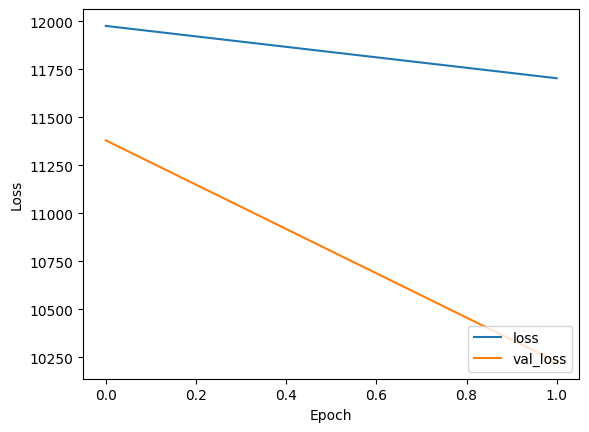

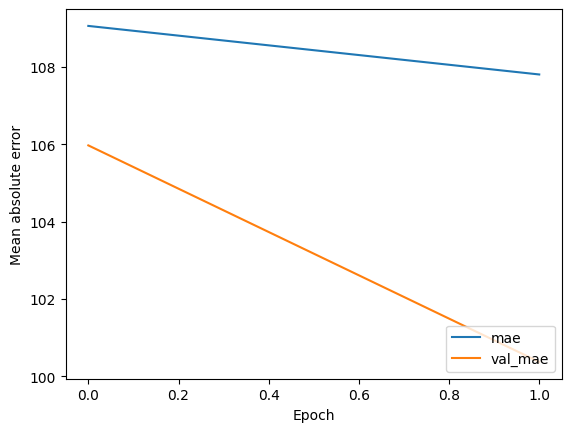

In [3]:
car = NNCar()
car.build_model()
car.train_model()
